In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots cleaner
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
# Load dataset
df = pd.read_csv("../data/raw/hotel_bookings.csv")

# Inspect first rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Check shape
print("Shape:", df.shape)

# Check missing values
df.isnull().sum()

Shape: (119390, 32)


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [4]:
df = df[df["is_canceled"] == 0].copy()

print("After removing cancellations:", df.shape)

After removing cancellations: (75166, 32)


In [5]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

# Drop invalid dates
df = df.dropna(subset=["arrival_date"])

In [6]:
# Remove zero or extreme ADR
upper_bound = df["adr"].quantile(0.99)

df = df[(df["adr"] > 0) & (df["adr"] < upper_bound)]

print("Cleaned shape:", df.shape)

Cleaned shape: (72665, 33)


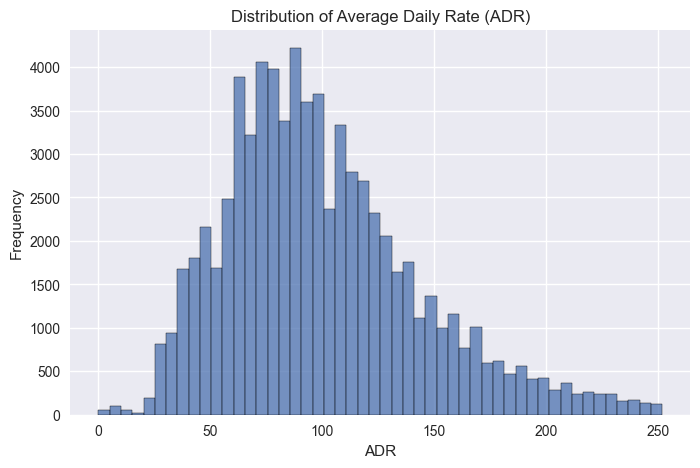

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["adr"], bins=50)
plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

In [8]:
daily = (
    df.groupby("arrival_date")
    .agg(
        daily_demand=("adr", "count"),
        avg_price=("adr", "mean")
    )
    .reset_index()
    .sort_values("arrival_date")
)

daily.head()

,arrival_date,daily_demand,avg_price
0,2015-07-01,100,95.368300
1,2015-07-02,36,99.188611
2,2015-07-03,37,99.524054
3,2015-07-04,44,90.669091
4,2015-07-05,37,107.966486


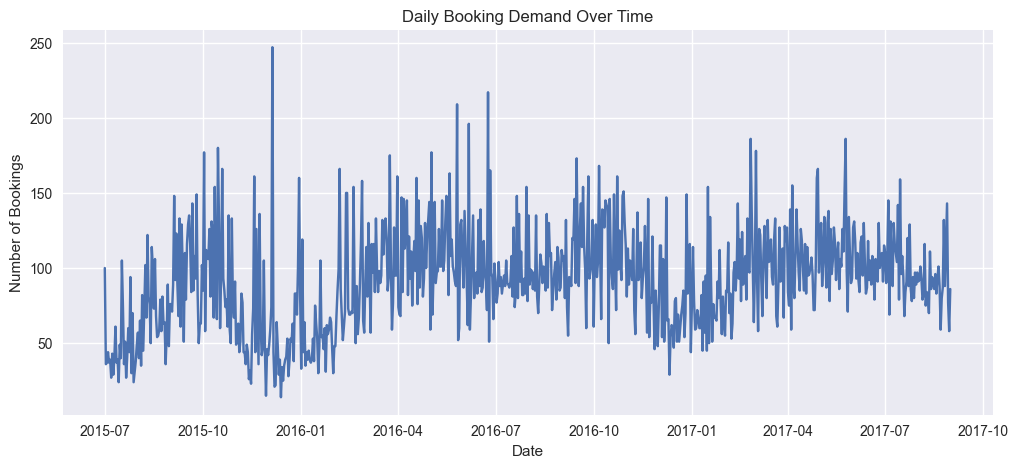

In [9]:
plt.figure(figsize=(12,5))
plt.plot(daily["arrival_date"], daily["daily_demand"])
plt.title("Daily Booking Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Bookings")
plt.show()

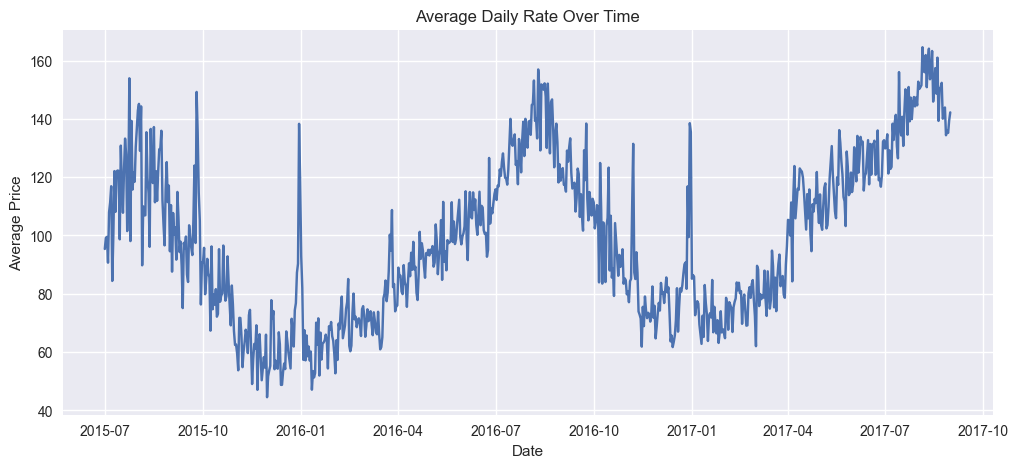

In [10]:
plt.figure(figsize=(12,5))
plt.plot(daily["arrival_date"], daily["avg_price"])
plt.title("Average Daily Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.show()

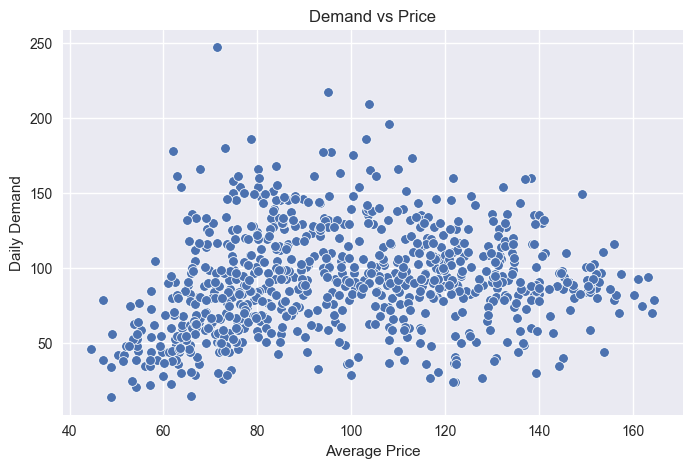

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=daily["avg_price"], y=daily["daily_demand"])
plt.title("Demand vs Price")
plt.xlabel("Average Price")
plt.ylabel("Daily Demand")
plt.show()

In [12]:
daily["month"] = daily["arrival_date"].dt.month
daily["day_of_week"] = daily["arrival_date"].dt.dayofweek
daily["is_weekend"] = daily["day_of_week"].isin([5,6]).astype(int)

daily.head()

,arrival_date,daily_demand,avg_price,month,day_of_week,is_weekend
0,2015-07-01,100,95.368300,7,2,0
1,2015-07-02,36,99.188611,7,3,0
2,2015-07-03,37,99.524054,7,4,0
3,2015-07-04,44,90.669091,7,5,1
4,2015-07-05,37,107.966486,7,6,1


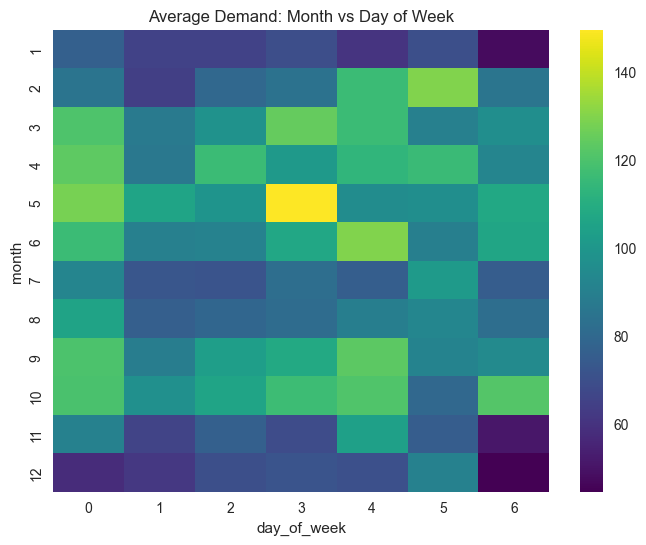

In [13]:
pivot = daily.pivot_table(
    values="daily_demand",
    index="month",
    columns="day_of_week",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Average Demand: Month vs Day of Week")
plt.show()

In [14]:
daily.to_csv("../data/processed/daily_aggregated.csv", index=False)

print("Saved cleaned daily dataset.")

Saved cleaned daily dataset.
